# Netflix User Churn — EDA Visualizations

## What I want to visualize
- Churn rate by subscription type
- Watch hours vs churn
- Last login days vs churn
- Churn by region
- Columns are most related to churn
- Mobile users more to churn to TV users?

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/netflix_customer_churn.csv')

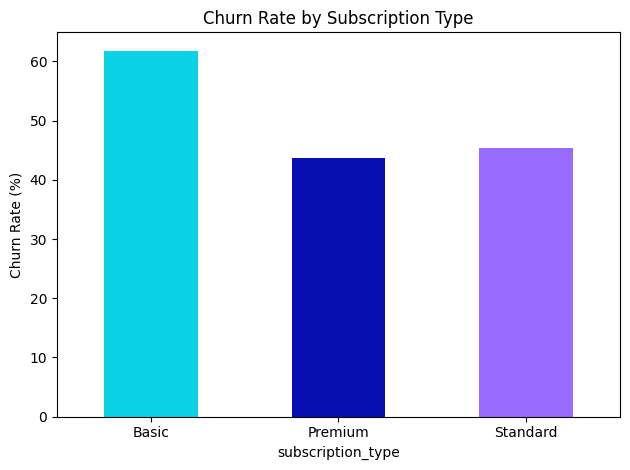

In [113]:
# Churn rate by subscription type
churn_by_plan = df.groupby('subscription_type')['churned'].mean() * 100

churn_by_plan.plot(kind='bar', color=["#09D3E5", "#070FB2", "#976BFF"])
plt.title('Churn Rate by Subscription Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Basic plan users churn at 61.8% — the highest of all plans.
Premium users are the most loyal at 43.7% churn.
Standard sits in the middle at 45.4%.
Users who pay more ($17.99) are 18% less likely to leave than users on the cheapest plan ($8.99).

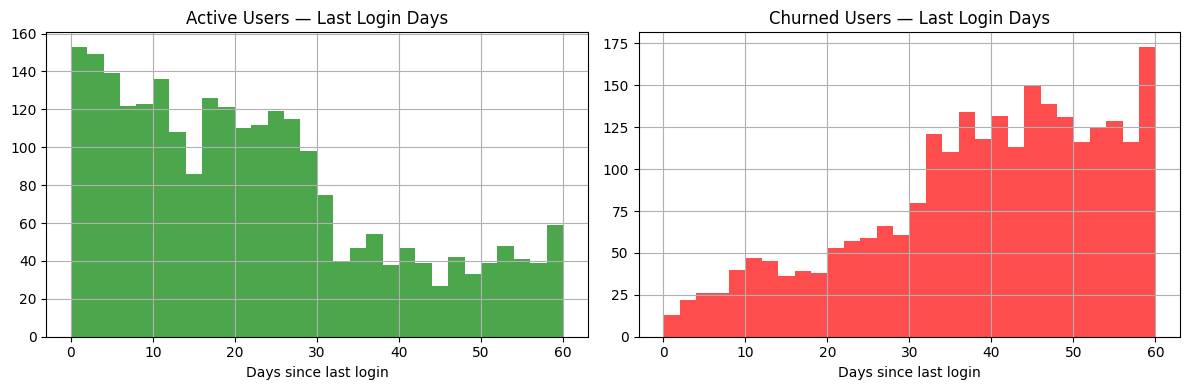

In [114]:
# Do churned users log in less often?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['churned']==0]['last_login_days'].hist(ax=axes[0], bins=30, color='green', alpha=0.7)
axes[0].set_title('Active Users — Last Login Days')
axes[0].set_xlabel('Days since last login')

df[df['churned']==1]['last_login_days'].hist(ax=axes[1], bins=30, color='red', alpha=0.7)
axes[1].set_title('Churned Users — Last Login Days')
axes[1].set_xlabel('Days since last login')

plt.tight_layout()
plt.show()

Churned users had not logged in for an average of 38 days.
Active users logged in every 22 days on average.
That is a 16 day difference — users inactive for more than 30 days are at high risk of cancelling.

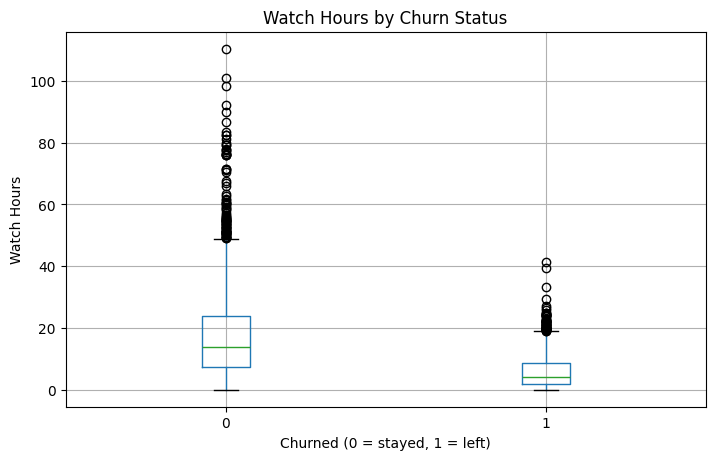

In [115]:
# Does watch time differ between churned and active users?
df.boxplot(column='watch_hours', by='churned', figsize=(8, 5))
plt.title('Watch Hours by Churn Status')
plt.suptitle('')
plt.xlabel('Churned (0 = stayed, 1 = left)')
plt.ylabel('Watch Hours')
plt.show()

Active users watch an average of 17.4 hours vs 15.9 hours for churned users.
That is a 1.5 hour difference.
Low watch time combined with high inactivity is the strongest warning sign of churn.

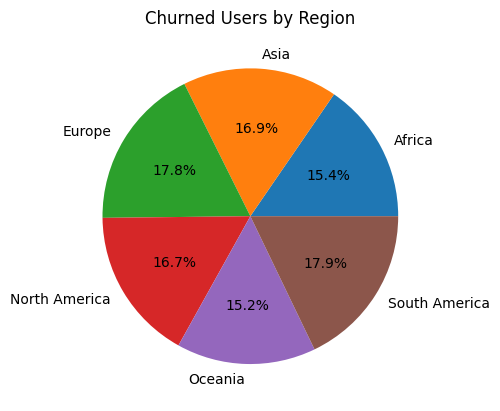

In [116]:
# Which region has the highest churn?
df.groupby('region')['churned'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Churned Users by Region')
plt.ylabel('')
plt.show()

Churn rates across regions range from roughly 15% to 18%.
No region stands out significantly — geography is not a useful predictor of churn.

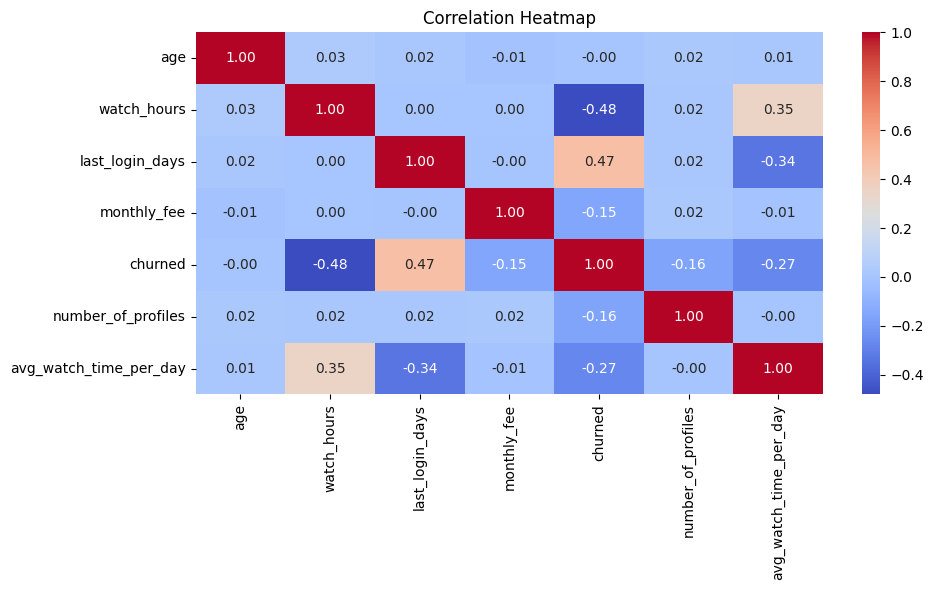

In [117]:
# Which features are most correlated with churn?
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Strongest correlations with churn:
- watch_hours: -0.48 (more watching = less churn)
- last_login_days: +0.47 (more inactivity = more churn)
- avg_watch_time_per_day: -0.27
- monthly_fee: -0.15 (price has very little impact)
Behaviour predicts churn better than price or demographics.

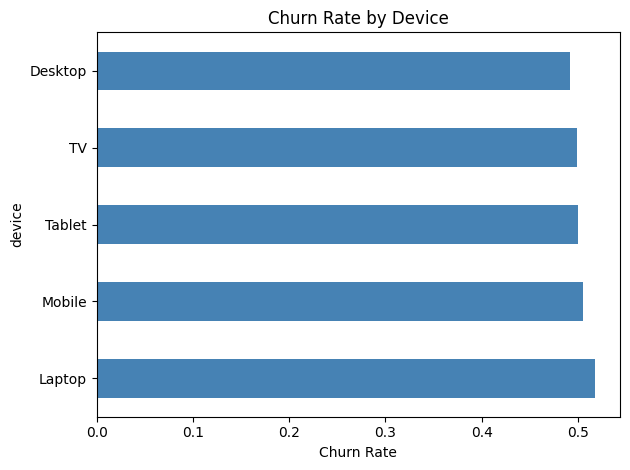

In [118]:
# Do certain devices have higher churn?
df.groupby('device')['churned'].mean().sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.title('Churn Rate by Device')
plt.xlabel('Churn Rate')
plt.tight_layout()
plt.show()

Churn rates by device range from 49% to 52%.
There is less than 3% difference between devices.
Device type does not meaningfully predict whether a user will cancel.